# Criando um classificador de Cachorros e Gatos

## Introdução
Este notebook tem como objetivo explorar imagens de cachorros e gatos e realizar classificações. 
A análise será dividida nas seguintes etapas:
1. Carregamento dos Dados
2. Análise Exploratória (EDA)
3. Treinamento do Modelo
4. Avaliação do Modelo

---

## 1. Carregamento de Bibliotecas e Configurações


In [43]:
!pip install pandas         --quiet
!pip install scikit-learn   --quiet
!pip install matplotlib     --quiet
!pip install numpy          --quiet

In [44]:
!pip install "vb-toolbox[ml] @ git+https://github.com/ViniLinharesBozzon/vb_toolbox.git" --quiet

In [ ]:
addadawdadaw

In [ ]:
# Arrumando problema de uso no Databricks:
try: 
    import numpy                                    as np
    import pandas                                   as pd
    import matplotlib.pyplot                        as plt
    import tensorflow
    import platform
    import pathlib
    import os
    from PIL                import Image,ImageOps
    from vb_toolbox.ml      import pre_analytics
except Exception as error:
    print(f"❌ Deu essa falha: {error}")
    if platform.node() == 'spark.host.local':
        dbutils.library.restartPython()

In [46]:
# verificando qual base de dados usar
if platform.node() != 'LAPTOP-9CTN2TQE':
    print("⚠️ Ambiente externo detectado")
    !pip install kagglehub --quiet

    # baixando a base de dados
    import kagglehub

    # Download latest version
    path = kagglehub.dataset_download("bhavikjikadara/dog-and-cat-classification-dataset")

    # Aqui ainda está no dataset
    c_pathImagens_str = path
    c_pathImagens_str = os.path.join(c_pathImagens_str,'PetImages')

    print("Path to dataset files:", c_pathImagens_str)
else:
    print("⚠️ Verificando o caminho local")
    c_pathImagens_str = 'dataset/PetImages'

c_pathCats_str    = c_pathImagens_str+'/Cat'
c_pathDogs_str    = c_pathImagens_str+'/Dog'

⚠️ Ambiente externo detectado
Path to dataset files: /root/.cache/kagglehub/datasets/bhavikjikadara/dog-and-cat-classification-dataset/versions/1/PetImages


---
## 2. Análise Exploratória(EDA)

 - As imagens tem proporção distintas em ambos os casos
 - Será necessário aplicar um tratamento em todas as imagens
 - Necessário replicar um forma de identificador para o treinamento.

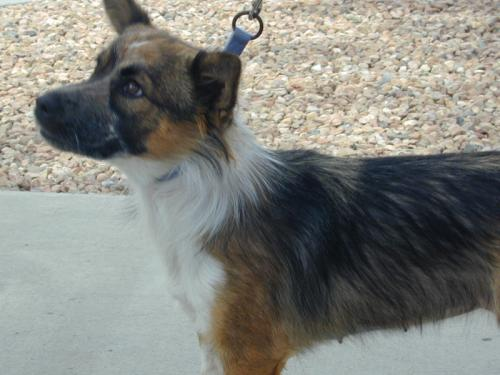

In [47]:
# Lendo uma imagem de cachorro
Image.open(c_pathDogs_str+'/3.jpg')

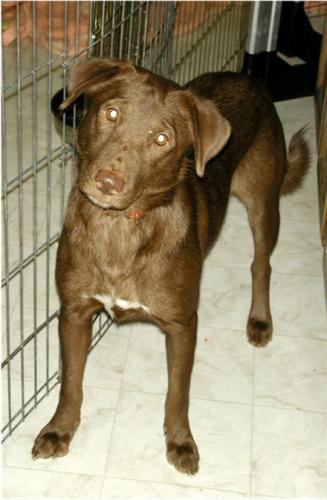

In [48]:
# Lendo uma imagem de cachorro
Image.open(c_pathDogs_str+'/1.jpg')

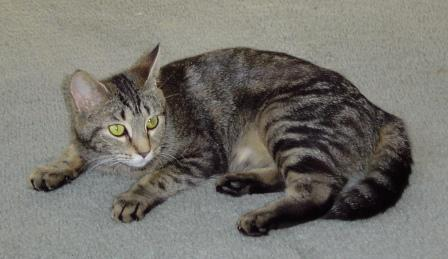

In [49]:
# verificando a base de gatos
Image.open(c_pathCats_str+'/16.jpg')

#### 2.2 Comparando imagem com e sem cor

In [50]:
v_fotoTeste_str = c_pathCats_str + '/16.jpg'

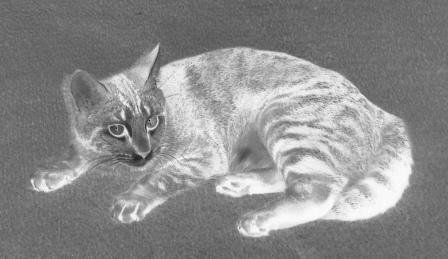

In [51]:
# Tentando aplicar a mesma regra da leitura de caractere
v_imagemTeste_pillow = Image.open(v_fotoTeste_str)
v_imagemTeste_pillow = v_imagemTeste_pillow.convert('L')
v_imagemTeste_pillow = ImageOps.invert(v_imagemTeste_pillow)
# v_imagemTeste_pillow = v_imagemTeste_pillow.resize((28,28))
v_imagemTeste_pillow

In [52]:
#### Provavelmente não fará sentido trocar a escala da imagem

--- 
## 3. Pre-Processamento
- Carregar a imagem dentro do vetor
- Usar o RGB Normalizado ( Rescaling )
- Redimensionar as imagens ( Reshape ) 


### 3.0 Procurando registros corrompidos

In [53]:
if platform.system() == 'Windows':
    !cd dataset/PetImages && dir
else:
    !cd dataset/PetImages && ls

/bin/bash: line 1: cd: dataset/PetImages: No such file or directory


In [54]:
# Removendo pastas de checkpoint
if platform.system() == 'Windows':
    !del "datasets/PetImages/.ipynb_checkpoints"
    !del "datasets/PetImages/Cat/.ipynb_checkpoints"
    !del "datasets/PetImages/Dogs/.ipynb_checkpoints"
else:
    !rm -rf "datasets/PetImages/.ipynb_checkpoints"
    !rm -rf "datasets/PetImages/Cat/.ipynb_checkpoints"
    !rm -rf "datasets/PetImages/Dogs/.ipynb_checkpoints"


In [55]:
# verificando se existe apenas a pasta de Cat e Dog.
## O tensorflow vai ler as pastas como classe por isso não pode haver nada que não seja as classes.
if platform.system() == 'Windows':
    !cd dataset/PetImages && dir
else:
    !cd dataset/PetImages && ls

/bin/bash: line 1: cd: dataset/PetImages: No such file or directory


In [56]:
# Verificando se existe alguma imagem corrompida
import tensorflow as tf
import os
import glob

# Pega a lista de todos os arquivos .jpg (recursivamente)
# O glob vai achar datasets/PetImages/Cat/*.jpg e Dog/*.jpg
image_paths = glob.glob(os.path.join(c_pathImagens_str, '*/*.jpg'))

print(f"Verificando {len(image_paths)} imagens com o próprio TensorFlow...")

deletados = 0

for image_path in image_paths:
    try:
        # 1. Lê os bytes do arquivo
        file_bytes = tf.io.read_file(image_path)
        
        # 2. Tenta decodificar usando a engine do TF
        # Isso força o TF a validar o cabeçalho e os dados
        img = tf.io.decode_image(file_bytes, channels=3, expand_animations=False)
        
    except Exception as e:
        # Se o TF reclamar (mesmo erro do treino), a gente apaga
        print(f"Arquivo podre encontrado: {image_path}")
        try:
            os.remove(image_path)
            deletados += 1
            print("--> DELETADO.")
        except:
            print("--> Erro ao tentar deletar.")

print("-" * 30)
print(f"Varredura Finalizada. Total deletado: {deletados}")

Verificando 24991 imagens com o próprio TensorFlow...


Corrupt JPEG data: 99 extraneous bytes before marker 0xd9
Corrupt JPEG data: 214 extraneous bytes before marker 0xd9
Corrupt JPEG data: 239 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1153 extraneous bytes before marker 0xd9
Corrupt JPEG data: 128 extraneous bytes before marker 0xd9
Corrupt JPEG data: 396 extraneous bytes before marker 0xd9
Corrupt JPEG data: 2226 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1403 extraneous bytes before marker 0xd9
Corrupt JPEG data: 65 extraneous bytes before marker 0xd9
Corrupt JPEG data: 252 extraneous bytes before marker 0xd9
Corrupt JPEG data: 162 extraneous bytes before marker 0xd9
Corrupt JPEG data: 228 extraneous bytes before marker 0xd9


------------------------------
Varredura Finalizada. Total deletado: 0


### 3.1 Separação de base de teste

In [57]:
c_pathImagens_pathlib    = pathlib.Path(c_pathImagens_str)
print(c_pathImagens_pathlib)

/root/.cache/kagglehub/datasets/bhavikjikadara/dog-and-cat-classification-dataset/versions/1/PetImages


In [58]:
# Constantes do modelo
c_batchSize_int         = 64 
c_imageHeight_int       = 180
c_imageWidth_int        = 180
c_validationSplit_floor = 0.2
c_seed_int              = 173

In [59]:
v_treinoDataset_tf  = tensorflow.keras.utils.image_dataset_from_directory(
    directory       = c_pathImagens_pathlib
,   validation_split= c_validationSplit_floor 
,   subset          = "training"
,   seed            = c_seed_int
,   image_size      = (c_imageHeight_int,c_imageWidth_int)
,   batch_size      = c_batchSize_int
)

Found 24991 files belonging to 2 classes.
Using 19993 files for training.


In [60]:
v_testeDataset_tf  = tensorflow.keras.utils.image_dataset_from_directory(
    directory       = c_pathImagens_pathlib
,   validation_split= c_validationSplit_floor 
,   subset          = "validation"
,   seed            = c_seed_int
,   image_size      = (c_imageHeight_int,c_imageWidth_int)
,   batch_size      = c_batchSize_int
)

Found 24991 files belonging to 2 classes.
Using 4998 files for validation.


In [61]:
# Verificando se as classes estão corretas:
print(v_treinoDataset_tf.class_names)
c_numeroClasses_int = len(v_treinoDataset_tf.class_names)

['Cat', 'Dog']


--- 
## 4. Treinamento do Modelo
- Usar o RGB Normalizado ( Rescaling )

A fazer:
Colocar Data Augmentation ( virar  as imagens ) 

In [62]:
v_modeloCNN_tf = tensorflow.keras.models.Sequential([
     tensorflow.keras.layers.Rescaling(1./255 , input_shape=(c_imageHeight_int,c_imageWidth_int,3)) # Normalizando o RGB e usando 3 camadas devido ao RGB
,    tensorflow.keras.layers.Conv2D(16,(3,3), activation="relu")                                    # Neuronios estao "fatiando" a imagem em imagens de (3x3) pixeis
,    tensorflow.keras.layers.MaxPooling2D((2,2))                                                    # Dividindo a imagem que vem do Conv2D pela metade.
,    tensorflow.keras.layers.Conv2D(32,(3,3), activation="relu")                                    # Neuronios estao "fatiando" a imagem em imagens de (3x3) pixeis
,    tensorflow.keras.layers.MaxPooling2D((2,2))                                                    # Dividindo a imagem que vem do Conv2D pela metade.
,    tensorflow.keras.layers.Conv2D(64,(3,3), activation="relu")                                    # Neuronios estao "fatiando" a imagem em imagens de (3x3) pixeis
,    tensorflow.keras.layers.MaxPooling2D((2,2))                                                    # Dividindo a imagem que vem do Conv2D pela metade.
,    tensorflow.keras.layers.Flatten()                                                              # Reorganiza os vetores das camadas para decisão
,    tensorflow.keras.layers.Dense(128, activation="relu")                                          # Decisão baseada nos fatiamentos das camadas.
,    tensorflow.keras.layers.Dropout(0.5)                                                           # Desligando metade dos neurônios durante o treinamento
,    tensorflow.keras.layers.Dense(c_numeroClasses_int, activation="softmax")                       # Decisão deve ser baseada pela quantidade de classes existentes: cães / gatos 
# e retornar em 0 - 100% de chance.
])

In [63]:
v_modeloCNN_tf.compile(
     optimizer='adam'
,    loss=tensorflow.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
,    metrics=['accuracy']
)

In [64]:
epochs=7
history = v_modeloCNN_tf.fit(
  v_treinoDataset_tf
, validation_data=v_testeDataset_tf
, epochs=epochs
)

Epoch 1/7


/usr/local/lib/python3.10/dist-packages/keras/src/backend.py:5714: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(
Corrupt JPEG data: 252 extraneous bytes before marker 0xd9


112/313 [=========>....................] - ETA: 3s - loss: 0.6686 - accuracy: 0.5956

Corrupt JPEG data: 1153 extraneous bytes before marker 0xd9


133/313 [===========>..................] - ETA: 3s - loss: 0.6591 - accuracy: 0.6062

...

304/313 [============================>.] - ETA: 0s - loss: 0.2130 - accuracy: 0.9130

Corrupt JPEG data: 228 extraneous bytes before marker 0xd9


313/313 [==============================] - ETA: 0s - loss: 0.2120 - accuracy: 0.9131

Corrupt JPEG data: 128 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1403 extraneous bytes before marker 0xd9


313/313 [==============================] - 7s 23ms/step - loss: 0.2120 - accuracy: 0.9131 - val_loss: 0.4904 - val_accuracy: 0.8201


---
# 5. Avaliando o Modelo

In [65]:
def f_set_avaliationImage(v_path_str):
    # 1- Lendo uma imagem
    img = tf.keras.utils.load_img(
        v_path_str, target_size=(c_imageHeight_int, c_imageWidth_int)
    ) 
    
    # 2. Converte a imagem para um array de números (matriz)
    img_array = tf.keras.utils.img_to_array(img)
    
    # 3. Cria um lote (batch) de uma imagem só
    # O modelo espera receber um lote, tipo (1, 180, 180, 3)
    img_array = tf.expand_dims(img_array, 0)
    
    # 4. Faz a previsão
    previsoes = v_modeloCNN_tf.predict(img_array)
    
    # 5. Traduz o resultado
    # Como usamos Softmax, 'previsoes' é uma lista de probabilidades: [ChanceGato, ChanceCachorro]
    score = previsoes[0]
    
    # Pega a classe com maior valor
    classe_vencedora_index = np.argmax(score)
    
    # Recupera os nomes das classes (que vimos lá no começo: ['Cat', 'Dog'])
    # Se você não salvou em uma variável, pode escrever na mão: nomes_classes = ['Gato', 'Cachorro']
    nomes_classes = v_treinoDataset_tf.class_names
    
    print(f"------------------------------------------------")
    print(f"Imagem: {v_path_str}")
    print(f"Resultado: {nomes_classes[classe_vencedora_index]}")
    print(f"Confiança: {100 * np.max(score):.2f}%")
    print(f"Detalhe: {score}") # Mostra os números brutos pra você ver

In [66]:
# v_imagePath_str = c_pathDogs_str+"/20.jpg"
v_imagePath_str = c_pathDogs_str+"/5445.jpg"
# v_imagePath_str = c_pathCats_str+"/40.jpg"

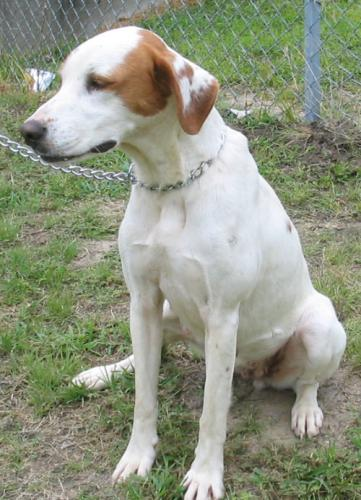

In [67]:
Image.open(v_imagePath_str)

In [68]:
f_set_avaliationImage(v_imagePath_str)

1/1 [==============================] - 0s 89ms/step
------------------------------------------------
Imagem: /root/.cache/kagglehub/datasets/bhavikjikadara/dog-and-cat-classification-dataset/versions/1/PetImages/Dog/5445.jpg
Resultado: Dog
Confiança: 99.97%
Detalhe: [2.7094607e-04 9.9972910e-01]


---
## 6. Exportando o modelo